In [1]:
# Step 1 - Read the dataset

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os

import cv2 as cv

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


import warnings
warnings.filterwarnings("ignore")

In [ ]:
train_dir = 'temp\\brain_tumor_dataset\\Training'
test_dir = 'temp\\brain_tumor_dataset\\Testing'

In [3]:
# Define a List for training and testing
X_train_list = [] 
y_train_list = []

In [4]:
# Class names

labels = os.listdir(train_dir)
print(labels)

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [5]:
# Define the image size and batch size

img_size = (150,150)
batch_size = 32

In [6]:
# Print the data path

for i in labels:
    path = os.path.join(train_dir, i)
    print(path)
 
print('-'*80)   
for i in labels:
    path = os.path.join(test_dir, i)
    print(path)

E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Training\glioma_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Training\meningioma_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Training\no_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Training\pituitary_tumor
--------------------------------------------------------------------------------
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Testing\glioma_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Testing\meningioma_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Testing\no_tumor
E:\UCT Training AIMLDS\GENAI_IITG_6Months\brain_tumor_dataset\Testing\pituitary_tumor


In [7]:
# Load the training data

for i in labels:
    path = os.path.join(train_dir, i)
    
    for j in os.listdir(path):
        image = cv.imread(os.path.join(path,j))
        image = cv.resize(image, img_size)
        X_train_list.append(image)
        y_train_list.append(i)
        
        
for i in labels:
    path = os.path.join(test_dir, i)
    
    for j in os.listdir(path):
        image = cv.imread(os.path.join(path, j))
        image = cv.resize(image, img_size)
        X_train_list.append(image)
        y_train_list.append(i)

In [8]:
X_train = np.array(X_train_list)
y_train = np.array(y_train_list)

In [9]:
len(X_train)

3264

In [10]:
X_train

array([[[[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],

        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],

        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],

        ...,

        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],

        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],

        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]]],


       [[[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0, 

In [11]:
len(y_train)

3264

In [12]:
# Shuffle the data

from sklearn.utils import shuffle
X_train,y_train = shuffle(X_train,y_train, random_state=101)
X_train.shape, y_train.shape

((3264, 150, 150, 3), (3264,))

In [13]:
X_train[0]

array([[[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       ...,

       [[54, 54, 54],
        [70, 70, 70],
        [69, 69, 69],
        ...,
        [ 1,  1,  1],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[42, 42, 42],
        [64, 64, 64],
        [69, 69, 69],
        ...,
        [ 1,  1,  1],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[28, 28, 28],
        [55, 55, 55],
        [64, 64, 64],
        ...,
        [ 1,  1,  1],
        [ 0,  0,  0],
        [ 0,  0,  0]]], dtype=uint8)

In [14]:
y_train[0]

np.str_('no_tumor')

In [15]:
y_train_index = []
for i in y_train:
    y_train_index.append(labels.index(i))
y_train = y_train_index
y_train[0]


2

In [16]:
X_train.dtype

dtype('uint8')

In [17]:
X_train  = np.array(X_train.astype('float32')) / 255.0

In [18]:
X_train[0]

array([[[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       ...,

       [[0.21176471, 0.21176471, 0.21176471],
        [0.27450982, 0.27450982, 0.27450982],
        [0.27058825, 0

In [19]:
y_train = np.array(y_train)

In [20]:
print(type(X_train), X_train.shape, X_train.dtype)

<class 'numpy.ndarray'> (3264, 150, 150, 3) float32


In [21]:
print(type(y_train), y_train.shape, y_train.dtype)

<class 'numpy.ndarray'> (3264,) int64


In [22]:
# Model V1

model_v1 = Sequential()

# Add the first convolutional layer
model_v1.add(Conv2D(32, (3, 3), activation = 'relu', input_shape = (img_size[0], img_size[1], 3)))
model_v1.add(BatchNormalization())
model_v1.add(MaxPooling2D(pool_size = (2, 2)))

# Add the second convolutional layer
model_v1.add(Conv2D(64, (3, 3), activation = 'relu'))
model_v1.add(BatchNormalization())
model_v1.add(MaxPooling2D(pool_size = (2, 2)))

# Add the third convolutional layer
model_v1.add(Conv2D(128, (3, 3), activation = 'relu'))
model_v1.add(BatchNormalization())
model_v1.add(MaxPooling2D(pool_size = (2, 2)))

# Add the fourth convolutional layer
model_v1.add(Conv2D(256, (3, 3), activation = 'relu'))
model_v1.add(BatchNormalization())
model_v1.add(MaxPooling2D(pool_size = (2, 2)))

# Add fully connected layers
model_v1.add(Flatten())
model_v1.add(Dense(512, activation = 'relu'))
model_v1.add(Dropout(0.3))
model_v1.add(Dense(256, activation = 'relu'))
model_v1.add(Dropout(0.5))
model_v1.add(Dense(4, activation = 'softmax'))
model_v1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,945,732 (26.50 MB)

 Trainable params: 6,944,772 (26.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [23]:
# Compile the model
model_v1.compile(optimizer = 'Adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X_train,y_train,test_size=0.2,random_state=101)
len(X_train),len(X_test),len(y_train),len(y_test)

(2611, 653, 2611, 653)

In [25]:
X_train.shape, y_train.shape

((2611, 150, 150, 3), (2611,))

In [26]:
y_train

array([2, 0, 2, ..., 1, 3, 1])

In [27]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=4)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=4)

In [ ]:
# Train the model: Will take 20 + minutes
history_v1 = model_v1.fit(X_train, y_train, epochs = 25, batch_size = batch_size, validation_data = (X_test, y_test), verbose = 1)

Epoch 1/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 51s 582ms/step - accuracy: 0.4316 - loss: 5.1295 - val_accuracy: 0.3017 - val_loss: 1.7802
Epoch 2/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 49s 592ms/step - accuracy: 0.5652 - loss: 1.4266 - val_accuracy: 0.3247 - val_loss: 2.7369
Epoch 3/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 48s 586ms/step - accuracy: 0.6275 - loss: 0.9687 - val_accuracy: 0.4824 - val_loss: 1.2529
Epoch 4/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 48s 582ms/step - accuracy: 0.6909 - loss: 0.7707 - val_accuracy: 0.6126 - val_loss: 0.9451
Epoch 5/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 49s 593ms/step - accuracy: 0.7156 - loss: 0.7095 - val_accuracy: 0.6172 - val_loss: 0.9629
Epoch 6/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 48s 590ms/step - accuracy: 0.7633 - loss: 0.5969 - val_accuracy: 0.8162 - val_loss: 0.4902
Epoch 7/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 48s 583ms/step - accuracy: 0.7813 - loss: 0.5442 - val_accuracy: 0.6753 - val_loss: 0.9613
Epoch 8/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 48s 580ms/step - accuracy: 0.8316 - loss: 0.4523 - val_accu

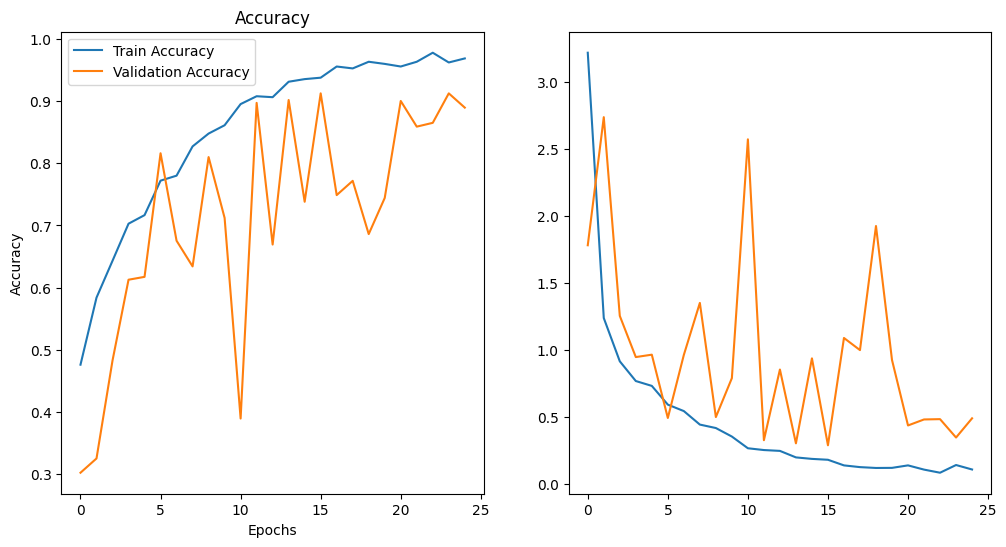

In [29]:
# Vizualizing the model performance

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_v1.history['accuracy'], label='Train Accuracy')
plt.plot(history_v1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_v1.history['loss'], label='Train Loss')
plt.plot(history_v1.history['val_loss'], label='Validation Loss')

plt.show()

In [30]:
y_pred = model_v1.predict(X_test)
y_pred

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step


array([[3.6245448e-05, 1.4988254e-03, 4.4754514e-05, 9.9842012e-01],
       [3.6093031e-10, 2.2406632e-12, 1.0000000e+00, 4.5981644e-16],
       [9.8921704e-01, 1.0771003e-02, 4.6732134e-06, 7.1951999e-06],
       ...,
       [2.8052944e-09, 9.6046058e-08, 8.6662055e-08, 9.9999976e-01],
       [2.7105141e-01, 7.2894663e-01, 1.8605234e-06, 5.5384849e-08],
       [1.4530726e-11, 1.2478446e-09, 6.5259957e-11, 1.0000000e+00]],
      dtype=float32)

In [31]:
y_pred_class = np.argmax(y_pred, axis=1)

In [32]:
y_pred_class

array([3, 2, 0, 1, 3, 1, 2, 3, 1, 1, 2, 1, 0, 1, 1, 3, 3, 2, 3, 2, 3, 0,
       1, 1, 1, 3, 2, 3, 3, 1, 1, 3, 0, 1, 3, 2, 3, 2, 0, 2, 2, 2, 3, 1,
       1, 3, 0, 1, 3, 1, 2, 0, 3, 3, 2, 3, 0, 3, 1, 0, 1, 1, 1, 1, 3, 3,
       1, 0, 2, 0, 2, 0, 3, 1, 0, 2, 0, 2, 2, 1, 1, 2, 3, 3, 0, 0, 1, 1,
       2, 1, 1, 3, 1, 1, 0, 1, 0, 2, 3, 1, 1, 1, 2, 2, 3, 3, 3, 0, 0, 2,
       1, 2, 3, 0, 3, 1, 2, 3, 2, 1, 0, 1, 3, 0, 3, 3, 1, 3, 3, 0, 1, 1,
       1, 3, 2, 1, 1, 3, 1, 1, 1, 1, 2, 0, 1, 1, 2, 2, 2, 2, 3, 1, 1, 3,
       2, 3, 2, 1, 2, 1, 3, 1, 1, 1, 1, 0, 0, 2, 0, 1, 1, 3, 3, 1, 2, 1,
       1, 0, 3, 0, 3, 0, 1, 0, 3, 2, 1, 1, 2, 1, 2, 1, 1, 2, 1, 1, 1, 1,
       1, 2, 3, 1, 3, 1, 2, 3, 2, 1, 1, 2, 1, 1, 2, 1, 0, 3, 1, 0, 3, 0,
       2, 1, 3, 1, 3, 0, 1, 1, 3, 2, 0, 0, 3, 0, 0, 2, 3, 3, 0, 0, 2, 0,
       1, 1, 2, 1, 2, 1, 0, 2, 0, 0, 1, 0, 0, 0, 3, 1, 3, 3, 0, 3, 3, 1,
       0, 0, 0, 1, 1, 0, 0, 3, 3, 3, 0, 3, 1, 2, 0, 1, 2, 1, 3, 3, 1, 1,
       0, 1, 1, 0, 2, 1, 1, 3, 3, 2, 3, 0, 0, 1, 2,

In [33]:
y_true_classes = np.argmax(y_test, axis=1)

In [40]:
# Confusion Matrix

cm = confusion_matrix(y_true_classes, y_pred_class)
print("Confusion Matric:\n", cm)

Confusion Matric:
 [[121  37  10   0]
 [  0 188   8   4]
 [  0   5 104   0]
 [  0   3   5 168]]


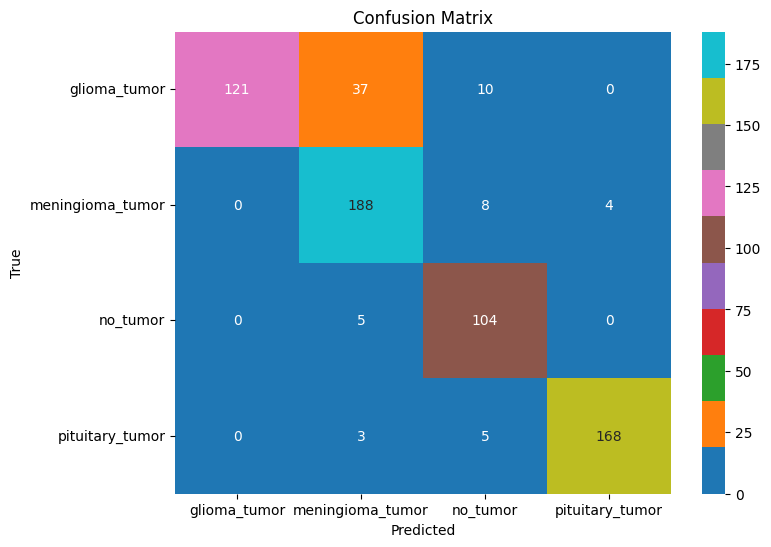

In [39]:
# Confusion Matrix with heatmap

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='tab10', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [41]:
print("Classification Report:\n", classification_report(y_true_classes, y_pred_class, target_names=labels))

Classification Report:
                   precision    recall  f1-score   support

    glioma_tumor       1.00      0.72      0.84       168
meningioma_tumor       0.81      0.94      0.87       200
        no_tumor       0.82      0.95      0.88       109
 pituitary_tumor       0.98      0.95      0.97       176

        accuracy                           0.89       653
       macro avg       0.90      0.89      0.89       653
    weighted avg       0.90      0.89      0.89       653



##### Regularized Model

From the accuracy plot, it is clearly visible that training could be stopped earlier for better performance.

So, model with **Early Stopping** 

In [42]:
early_stop = EarlyStopping(monitor="val_loss",
    min_delta=0.01,
    patience=5,
    verbose=1,
    restore_best_weights=False,
)

In [44]:
history_v2 = model_v1.fit(X_train, y_train, epochs=25, batch_size=batch_size, validation_data=(X_test, y_test), verbose=1,
                          callbacks=[early_stop])

Epoch 1/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 51s 599ms/step - accuracy: 0.9693 - loss: 0.0862 - val_accuracy: 0.6478 - val_loss: 2.4688
Epoch 2/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 53s 642ms/step - accuracy: 0.9704 - loss: 0.1060 - val_accuracy: 0.9066 - val_loss: 0.3392
Epoch 3/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 51s 622ms/step - accuracy: 0.9763 - loss: 0.0594 - val_accuracy: 0.9296 - val_loss: 0.4146
Epoch 4/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 49s 595ms/step - accuracy: 0.9851 - loss: 0.0434 - val_accuracy: 0.8530 - val_loss: 0.9183
Epoch 5/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 48s 586ms/step - accuracy: 0.9780 - loss: 0.0822 - val_accuracy: 0.6646 - val_loss: 3.8893
Epoch 6/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 48s 583ms/step - accuracy: 0.9889 - loss: 0.0434 - val_accuracy: 0.9066 - val_loss: 0.3657
Epoch 7/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 47s 567ms/step - accuracy: 0.9767 - loss: 0.0702 - val_accuracy: 0.8882 - val_loss: 0.5686
Epoch 7: early stopping


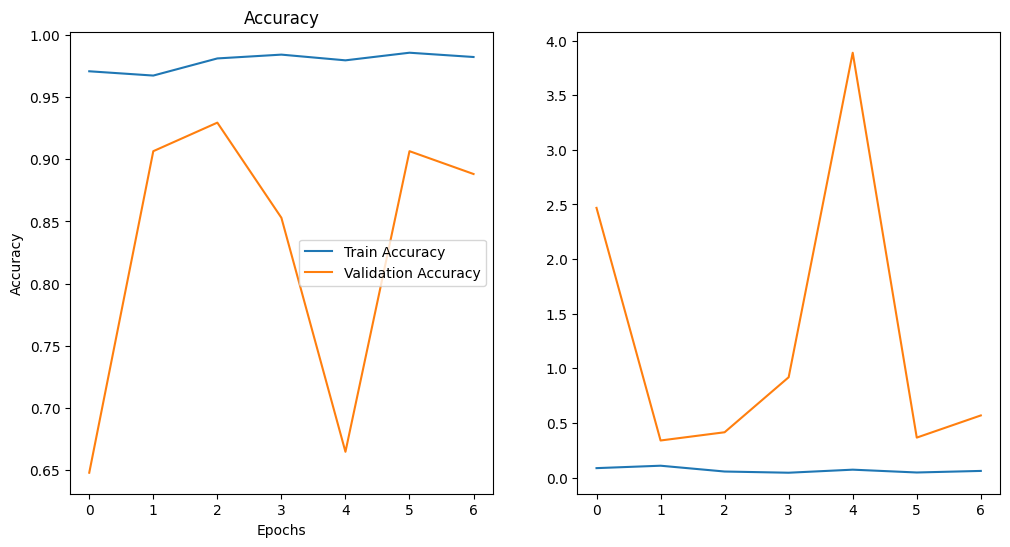

In [45]:
# Vizualizing the model performance

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_v2.history['accuracy'], label='Train Accuracy')
plt.plot(history_v2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_v2.history['loss'], label='Train Loss')
plt.plot(history_v2.history['val_loss'], label='Validation Loss')

plt.show()

In [46]:
y_pred2 = model_v1.predict(X_test)
y_pred2_class = np.argmax(y_pred2, axis=1)
print(y_pred2_class)

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step
[3 2 0 1 3 1 2 1 1 1 2 1 0 1 1 3 3 2 3 2 3 0 1 1 1 3 2 3 3 1 1 3 1 1 3 2 3
 1 1 2 2 0 3 1 1 3 0 1 3 1 2 0 3 3 1 3 0 3 1 0 1 1 1 0 1 3 3 0 2 0 2 0 3 1
 0 2 0 1 2 1 1 2 3 3 0 0 1 1 2 1 1 3 1 1 0 1 0 2 3 1 1 1 2 2 3 3 3 0 1 2 1
 0 3 0 3 0 2 3 2 1 0 1 3 0 3 3 1 3 3 0 1 0 1 3 2 1 1 3 1 1 1 1 2 0 1 1 0 2
 2 2 3 1 1 3 2 3 1 1 2 1 3 2 1 1 1 0 0 1 0 1 2 3 3 1 0 1 0 0 3 0 3 1 1 0 3
 2 1 1 2 1 2 1 0 2 1 1 1 1 1 2 3 1 3 1 2 3 2 1 1 2 1 1 1 1 0 3 0 0 3 0 2 1
 3 1 3 0 1 1 3 2 1 0 3 0 0 2 3 3 1 0 2 0 1 2 0 0 2 1 0 1 0 0 1 1 0 0 3 1 3
 3 0 3 3 1 0 0 0 1 2 0 0 3 3 3 0 3 1 1 0 1 2 1 3 3 1 1 0 1 1 0 2 1 1 3 3 2
 3 0 0 1 3 3 1 2 1 1 1 3 0 1 3 1 2 3 1 0 1 1 3 3 2 0 1 0 0 1 3 1 3 1 2 3 1
 1 1 1 2 2 0 3 2 1 3 1 0 1 2 1 3 3 2 0 1 0 1 2 3 3 1 3 3 1 3 1 2 2 2 2 0 3
 1 2 1 1 1 3 1 2 0 1 1 1 1 3 1 1 1 1 1 3 1 3 1 2 3 1 3 3 1 1 1 3 1 1 3 3 0
 1 0 3 1 3 2 2 2 1 3 2 1 1 3 1 2 3 3 0 1 0 1 1 1 1 1 0 1 0 3 1 0 0 3 2 0 2
 1 0 0 3 0 3 1 3 1 1 1 1 0 1 0 2 2 2 0 1 0 1 2 0 3 2 0 1 1 

In [47]:
cm = confusion_matrix(y_true_classes, y_pred2_class)
print("Confusion Matric:\n", cm)

Confusion Matric:
 [[121  41   4   2]
 [  1 194   1   4]
 [  1   5 103   0]
 [  0  11   3 162]]


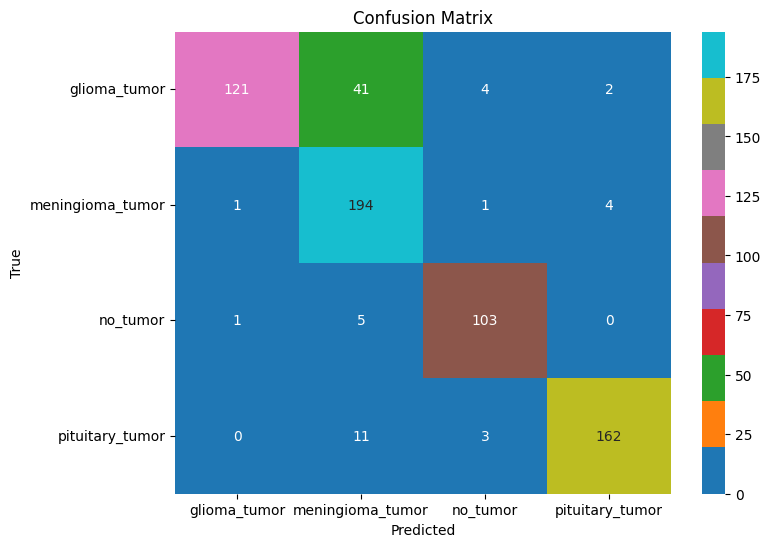

In [48]:
# Confusion Matrix with heatmap

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='tab10', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [49]:
print("Classification Report:\n", classification_report(y_true_classes, y_pred_class, target_names=labels))

Classification Report:
                   precision    recall  f1-score   support

    glioma_tumor       1.00      0.72      0.84       168
meningioma_tumor       0.81      0.94      0.87       200
        no_tumor       0.82      0.95      0.88       109
 pituitary_tumor       0.98      0.95      0.97       176

        accuracy                           0.89       653
       macro avg       0.90      0.89      0.89       653
    weighted avg       0.90      0.89      0.89       653



(619, 495, 3)


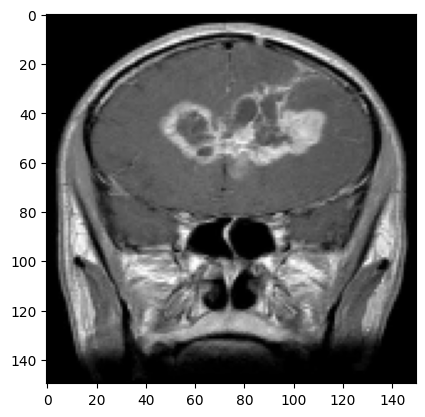

In [ ]:
# Reading Image from directory
test_img = cv.imread("temp\\brain_tumor_dataset\\Testing\\glioma_tumor\\image.jpg")
plt.imshow(test_img)
print(test_img.shape)

# Resize image
test_img = cv.resize(test_img,(150,150))
plt.imshow(test_img)
test_input = test_img.reshape(1,150,150,3)


In [53]:
# Predicting the image
pred = model_v1.predict(test_input)
pred_class = np.argmax(pred, axis=1)
print(pred_class)
print(labels[pred_class[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
[0]
glioma_tumor
